![Residual](./images/resnet-block.svg)

In [79]:
import os
# 设置当前目录为指定路径
os.chdir("/root/Project/learn")
import torch
import torch.nn as nn
from torch.nn import functional as F

In [80]:
class Residual(nn.Module):
    def __init__(self,input_channles,num_channles,use_1x1conv=False,stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=input_channles,out_channels=num_channles,kernel_size=3,stride=stride,padding=1)
        self.conv2 = nn.Conv2d(num_channles,num_channles,kernel_size=3,stride=1,padding=1)
        if use_1x1conv:
            self.conv3 = nn.Conv2d(in_channels=input_channles,out_channels=num_channles,kernel_size=1,stride=stride)
        else:
            self.conv3 = None
        self.bn1 = nn.BatchNorm2d(num_channles)
        self.bn2 = nn.BatchNorm2d(num_channles)

    def forward(self,X):
        X1 = F.relu(self.bn1(self.conv1(X)))
        X2 = self.bn2(self.conv2(X1))
        if self.conv3 is not None:
            X3 = self.conv3(X)
        else:
            X3 = X
        return F.relu(X2 + X3)

In [81]:
X = torch.rand(4, 3, 6, 6)
blk = Residual(3,3)
Y = blk(X)
Y.shape

torch.Size([4, 3, 6, 6])

![Resnet_18](./images/resnet18.svg)

In [82]:
def resnet_block(input_channels,num_channels,num_residuals,first_blk=False):
    blk = []
    for i in range(num_residuals):
        if i == 0 and not first_blk:
            blk.append(Residual(input_channels,num_channels,use_1x1conv=True,stride=2))
        else:
            blk.append(Residual(num_channels,num_channels,stride=1))
    return blk

In [83]:
b1 = nn.Sequential(nn.Conv2d(1,64,kernel_size=7,stride=2,padding=3),
                   nn.BatchNorm2d(64),nn.ReLU(),
                   nn.MaxPool2d(kernel_size=3,stride=2,padding=1))
b2 = nn.Sequential(*resnet_block(64,64,2,first_blk=True))
b3 = nn.Sequential(*resnet_block(64,128,2))
b4 = nn.Sequential(*resnet_block(128,256,2))
b5 = nn.Sequential(*resnet_block(256,512,2))

In [84]:
net = nn.Sequential(b1,b2,b3,b4,b5,
                    nn.AdaptiveAvgPool2d((1,1)),
                    nn.Flatten(),
                    nn.Linear(512,10))

In [85]:
X = torch.rand(size=(1, 1, 224, 224))
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape:\t', X.shape)

Sequential output shape:	 torch.Size([1, 64, 56, 56])
Sequential output shape:	 torch.Size([1, 64, 56, 56])
Sequential output shape:	 torch.Size([1, 128, 28, 28])
Sequential output shape:	 torch.Size([1, 256, 14, 14])
Sequential output shape:	 torch.Size([1, 512, 7, 7])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 512, 1, 1])
Flatten output shape:	 torch.Size([1, 512])
Linear output shape:	 torch.Size([1, 10])


In [86]:
import os
print(os.getcwd())  # 打印当前工作目录
from py09_FashionMNIST_Dataset import load_data_fashion_mnist
from deeplearn_tools import Animator,evaluate_accuracy,Timer

/root/Project/learn


In [87]:
batch_size = 256
lr = 1e-4
num_epoches = 10

In [88]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(net.parameters(),lr=lr)

In [89]:
train_loader,test_loader = load_data_fashion_mnist(batch_size=batch_size,resize=96)

In [90]:
def train(train_loader,test_loader,net,num_epoches,loss_fn,optimizer,device="cuda"):
    def init_weights(layer):
        if type(layer)== nn.Linear or type(layer) == nn.Conv2d:
            nn.init.xavier_uniform_(layer.weight)
    net.apply(init_weights)
    net.to(device)
    data_dis = Animator(xlabel='num_epoch',xlim=[1,num_epoches],legend=['train_loss','train_accuracy','test_accuracy'],yscale='log')
    timer = Timer()
    for epoch in range(num_epoches):
        l_sum = 0
        timer.start()
        for i,(X,y) in enumerate(train_loader):
            X,y = X.to(device),y.to(device)
            optimizer.zero_grad()
            y_hat = net(X)
            l = loss_fn(y_hat,y)
            l.backward()
            optimizer.step()
            l_sum += l
        epoch_time = timer.stop()
        with torch.no_grad():
            train_acc = evaluate_accuracy(net,train_loader,device)
            test_acc = evaluate_accuracy(net,test_loader,device)
        print(f"{epoch}:train loss,{l_sum:.2f},train_acc:{train_acc},test_acc:{test_acc},time:{epoch_time:.4f}s")
        data_dis.add(epoch+1,[l_sum,train_acc,test_acc])
    with torch.no_grad():
        train_acc = evaluate_accuracy(net,train_loader,device)
        test_acc = evaluate_accuracy(net,test_loader,device)
        print(f"{num_epoches},train_acc:{train_acc},test_acc:{test_acc}")
        print(f"avg_time:{timer.avg()}")

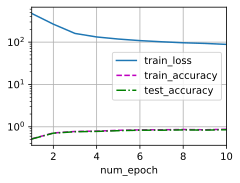

In [91]:
train(train_loader,test_loader,net,num_epoches,loss_fn,optimizer)

In [92]:
with torch.no_grad():
    train_acc = evaluate_accuracy(net,train_loader,"cuda")
    test_acc = evaluate_accuracy(net,test_loader,"cuda")
    print(f"{num_epoches},train_acc:{train_acc},test_acc:{test_acc}")

10,train_acc:0.8766666666666667,test_acc:0.8515
